In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix, issparse
import re
import warnings
from google.colab import drive

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_PATH = "/content/drive/MyDrive/independent-medical-review-imr-determinations-trends.csv"
OUTPUT_DIR = "results" # Directory to save results
MAX_TFIDF_FEATURES = 500    # Number of TF-IDF features

In [5]:
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Load the IMR CSV and prepare it for modeling

    Reads the CSV, creates a binary target variable from the Determination
    column (1 = Overturned, 0 = Upheld), fills missing demographic values,
    and combines text fields into a single column for TF-IDF

    Args:
        filepath (str): Path to the IMR CSV file

    Returns:
        pd.DataFrame: Cleaned DataFrame ready for feature engineering
    """
    print(f"Reading: {filepath}")
    df = pd.read_csv(filepath, low_memory=False, on_bad_lines="skip")
    print(f"Raw records: {len(df):,}")

    # Binary target: 1 = Overturned (favorable to patient), 0 = Upheld
    df["Overturned"] = df["Determination"].str.contains(
        "Overturned", case=False, na=False
    ).astype(int)

    # Fill missing demographics
    df["PatientGender"] = df["PatientGender"].fillna("Unknown").str.strip()
    df["AgeRange"] = df["AgeRange"].fillna("Unknown").str.strip()

    # Findings is excluded — it is the reviewer's post-decision narrative
    # and contains literal "overturned"/"upheld" phrasing that leaks the target
    text_cols = ["DiagnosisCategory", "DiagnosisSubCategory",
                 "TreatmentCategory", "TreatmentSubCategory", "IMRType", "Type"]
    for col in text_cols:
        df[col] = df[col].fillna("").astype(str).str.strip()

    # Combined text field for TF-IDF
    df["combined_text"] = df[text_cols].apply(
        lambda row: " ".join(row.values), axis=1
    )

    print(f"Clean records: {len(df):,}")
    print(f"Target: {df['Overturned'].value_counts().to_dict()}")
    print(f"Gender: {df['PatientGender'].value_counts().to_dict()}")

    return df.reset_index(drop=True)

In [6]:
def explore_data(df: pd.DataFrame, output_dir: str):
    """
    Print and save overturn rates by gender and age group.

    Args:
        df (pd.DataFrame): Cleaned DataFrame from load_and_clean_data.
        output_dir (str): Directory to save exploration_stats.json.
    """
    os.makedirs(output_dir, exist_ok=True)  # <-- add this line

    overturn_by_gender = df.groupby("PatientGender")["Overturned"].mean()
    overturn_by_age = df.groupby("AgeRange")["Overturned"].mean()

    print(" -- Overturn Rates by Group --")
    for gender, rate in overturn_by_gender.items():
        print(f"Gender={gender}: {rate:.3f}")
    print()
    for age, rate in sorted(overturn_by_age.items()):
        print(f"Age={age}: {rate:.3f}")

    # Save stats to JSON
    stats = {
        "total_records": len(df),
        "target_distribution": df["Overturned"].value_counts().to_dict(),
        "gender_distribution": df["PatientGender"].value_counts().to_dict(),
        "age_distribution": df["AgeRange"].value_counts().to_dict(),
        "overturn_rate_by_gender": overturn_by_gender.to_dict(),
        "overturn_rate_by_age": overturn_by_age.to_dict(),
    }
    with open(os.path.join(output_dir, "exploration_stats.json"), "w") as f:
        json.dump(stats, f, indent=2, default=str)

In [7]:
print("Loading and cleaning data...")
df = load_and_clean_data(DATA_PATH)

Loading and cleaning data...
Reading: /content/drive/MyDrive/independent-medical-review-imr-determinations-trends.csv
Raw records: 40,921
Clean records: 40,921
Target: {1: 21152, 0: 19769}
Gender: {'Female': 23059, 'Male': 17086, 'Unknown': 691, 'Other': 85}


In [8]:
explore_data(df, OUTPUT_DIR)

 -- Overturn Rates by Group --
Gender=Female: 0.526
Gender=Male: 0.511
Gender=Other: 0.635
Gender=Unknown: 0.337

Age=0 to 10: 0.659
Age=11 to 20: 0.555
Age=21 to 30: 0.545
Age=31 to 40: 0.532
Age=41 to 50: 0.485
Age=51 to 64: 0.498
Age=65+: 0.454
Age=Unknown: 0.337


In [9]:
def clean_text(text: str) -> str:
    """
    Basic text cleaning for TF-IDF.

    Lowercases the text, removes special characters,
    and collapses extra whitespace.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [10]:
def build_features(df: pd.DataFrame, max_tfidf: int = 500):
    """
    Build the full feature matrix from the cleaned IMR data

    Combines TF-IDF text features, one-hot encoded demographics,
    one-hot encoded categorical columns, and the report year into
    a single sparse matrix

    Args:
        df (pd.DataFrame): Cleaned DataFrame from load_and_clean_data.
        max_tfidf (int): Maximum number of TF-IDF features to keep

    Returns:
        X: Sparse feature matrix (n_samples × n_features).
        y: Binary target array (1 = Overturned, 0 = Upheld).
        feature_names: List of feature names matching X's columns.
        sensitive_attrs: DataFrame with PatientGender and AgeRange
            for fairness evaluation
    """
    # TF-IDF on combined text (Term Frequency - Inverse Document Frequency)
    df["clean_text"] = df["combined_text"].apply(clean_text)

    tfidf = TfidfVectorizer(
        max_features=max_tfidf,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True,
    )
    X_tfidf = tfidf.fit_transform(df["clean_text"])
    tfidf_names = [f"tfidf_{name}" for name in tfidf.get_feature_names_out()]

    # Demographic features (one-hot)
    gender_dummies = pd.get_dummies(df["PatientGender"], prefix="gender")
    age_dummies = pd.get_dummies(df["AgeRange"], prefix="age")

    # Categorical features (one-hot, top 20 per column)
    cat_cols = ["DiagnosisCategory", "TreatmentCategory", "IMRType", "Type"]
    cat_dummies_list = []
    cat_names = []
    for col in cat_cols:
        top_cats = df[col].value_counts().head(20).index
        temp = df[col].where(df[col].isin(top_cats), other="Other")
        dummies = pd.get_dummies(temp, prefix=col.lower())
        cat_dummies_list.append(dummies)
        cat_names.extend(list(dummies.columns))

    # Year feature
    year_feature = df[["ReportYear"]].fillna(df["ReportYear"].median())

    # Combine everything into one sparse matrix
    dense_parts = [gender_dummies.values, age_dummies.values]
    for cd in cat_dummies_list:
        dense_parts.append(cd.values)
    dense_parts.append(year_feature.values)

    X_dense = np.hstack(dense_parts)
    X = hstack([X_tfidf, csr_matrix(X_dense)])

    feature_names = (tfidf_names
                     + list(gender_dummies.columns)
                     + list(age_dummies.columns)
                     + cat_names
                     + ["ReportYear"])
    y = df["Overturned"].values
    sensitive_attrs = df[["PatientGender", "AgeRange"]].copy()

    print(f"TF-IDF features: {len(tfidf_names)}")
    print(f"Demographic features: {gender_dummies.shape[1] + age_dummies.shape[1]}")
    print(f"Categorical features: {len(cat_names)}")
    print(f"Total features: {X.shape[1]}")

    return X, y, feature_names, sensitive_attrs

In [11]:
def split_data(X, y, sensitive_attrs, test_size=0.2, random_state=42):
    """
    Stratified train/test split that keeps sensitive attributes aligned.

    Args:
        X: Feature matrix.
        y: Target array.
        sensitive_attrs: DataFrame with demographic columns.
        test_size (float): Fraction of data for testing.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train, X_test, y_train, y_test, sens_train, sens_test
    """
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=random_state, stratify=y
    )

    return (
        X[train_idx], X[test_idx],
        y[train_idx], y[test_idx],
        sensitive_attrs.iloc[train_idx].reset_index(drop=True),
        sensitive_attrs.iloc[test_idx].reset_index(drop=True),
    )

In [12]:
print("Building features (TF-IDF + demographics)...")
X, y, feature_names, sensitive_attrs = build_features(
    df, max_tfidf=MAX_TFIDF_FEATURES
)
X_train, X_test, y_train, y_test, sens_train, sens_test = split_data(
    X, y, sensitive_attrs
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X.shape[1]}")


Building features (TF-IDF + demographics)...
TF-IDF features: 500
Demographic features: 12
Categorical features: 47
Total features: 560
Train: 32,736 | Test: 8,185 | Features: 560


In [13]:
# Only TF-IDF features (the text ones)
[f for f in feature_names if f.startswith("tfidf_")]

['tfidf_ablat',
 'tfidf_abuse',
 'tfidf_abuse addict',
 'tfidf_abuse mental',
 'tfidf_acute',
 'tfidf_acute med',
 'tfidf_acute psych',
 'tfidf_addict',
 'tfidf_adhd',
 'tfidf_admission',
 'tfidf_admission expedited',
 'tfidf_admission standard',
 'tfidf_admit',
 'tfidf_admit expedited',
 'tfidf_admit standard',
 'tfidf_alternative',
 'tfidf_alternative tx',
 'tfidf_analysis',
 'tfidf_analysis expedited',
 'tfidf_anti',
 'tfidf_anti inflammatories',
 'tfidf_anti virals',
 'tfidf_anxiety',
 'tfidf_anxiety mental',
 'tfidf_apnea',
 'tfidf_appld',
 'tfidf_appld behav',
 'tfidf_applicable',
 'tfidf_applicable diag',
 'tfidf_approved',
 'tfidf_approved use',
 'tfidf_arthritis',
 'tfidf_arthritis rx',
 'tfidf_artificial',
 'tfidf_artificial disc',
 'tfidf_asthma',
 'tfidf_autism',
 'tfidf_autism pdd',
 'tfidf_autism related',
 'tfidf_autism spectrum',
 'tfidf_autistic',
 'tfidf_autistic disorder',
 'tfidf_bariatric',
 'tfidf_beam',
 'tfidf_beam expedited',
 'tfidf_behav',
 'tfidf_behav analy

In [14]:
# Only gender features
[f for f in feature_names if f.startswith("gender_")]

['gender_Female', 'gender_Male', 'gender_Other', 'gender_Unknown']

In [15]:
# Only age features
[f for f in feature_names if f.startswith("age_")]

['age_0 to 10',
 'age_11 to 20',
 'age_21 to 30',
 'age_31 to 40',
 'age_41 to 50',
 'age_51 to 64',
 'age_65+',
 'age_Unknown']

In [16]:
# Train Logestic Regression
"""
Logistic Regression — Linear baseline.

Uses balanced class weights to handle imbalanced outcomes.
The SAGA solver supports both L1 and L2 regularization and
scales well to large datasets.
"""
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    C=1.0,
    random_state=42,
    n_jobs=-1,
)

lr_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [17]:
# Train Multinomial Naive Bayes
"""
Multinomial Naive Bayes — Probabilistic baseline.

Assumes feature independence, which means it cannot learn
interactions between demographic and clinical features.
Works natively with TF-IDF sparse matrices.
Alpha parameter controls Laplace smoothing.
"""
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train, y_train)
print("Multinomial Naive Bayes trained successfully.")

Multinomial Naive Bayes trained successfully.


In [18]:
# Train Random Forest
"""
Random Forest — Bagging ensemble.

Builds independent decision trees on random data subsets,
averaging their votes. The random feature selection at each
split naturally dilutes any single feature's influence.
"""
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [19]:
# Train AdaBoost
"""
AdaBoost — Sequential boosting ensemble.

Trains weak learners sequentially, giving more weight to
misclassified samples each round. If certain demographic
groups are harder to classify, AdaBoost will focus on them,
potentially amplifying existing data patterns.
"""
ada_model = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42,
)

ada_model.fit(X_train, y_train)
print("AdaBoost trained successfully.")

AdaBoost trained successfully.


In [20]:
# Train XGBoost
"""
XGBoost — Advanced gradient boosting.

Uses regularized gradient boosting with level-wise tree growth.
Scale_pos_weight handles class imbalance. Industry standard
for tabular classification tasks.
"""
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained successfully.")

XGBoost trained successfully.


In [21]:
# Train LightGBM
"""
LightGBM — Histogram-based gradient boosting (Microsoft).

Uses leaf-wise tree growth instead of level-wise, growing
deeper on the most informative splits first. This different
growth strategy may lead to different feature reliance
patterns compared to XGBoost.
"""
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(X_train, y_train)
print("LightGBM trained successfully.")

LightGBM trained successfully.


In [22]:
# storing all trained models in one dictionary
models = {
    "Logistic Regression": lr_model,
    "Multinomial Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
}

if xgb_model is not None:
    models["XGBoost"] = xgb_model

if lgbm_model is not None:
    models["LightGBM"] = lgbm_model

print("Models ready for evaluation:")
print(list(models.keys()))

Models ready for evaluation:
['Logistic Regression', 'Multinomial Naive Bayes', 'Random Forest', 'AdaBoost', 'XGBoost', 'LightGBM']


In [23]:
def evaluate_one_model(model, X_test, y_test):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = np.zeros(len(y_test))

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

In [24]:
# evaluate all trained models
all_metrics = {}
predictions = {}
probabilities = {}

for model_name, model in models.items():
    metrics, y_pred, y_prob = evaluate_one_model(model, X_test, y_test)
    all_metrics[model_name] = metrics
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

performance_df = pd.DataFrame(all_metrics).T.sort_values("F1", ascending=False)
performance_df.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.6718,0.7219,0.5939,0.6517,0.7411
LightGBM,0.6676,0.7135,0.5963,0.6497,0.7422
Multinomial Naive Bayes,0.6293,0.6548,0.5984,0.6253,0.6815
Logistic Regression,0.5797,0.5949,0.5861,0.5905,0.6172
Random Forest,0.6505,0.7496,0.4862,0.5898,0.7172
AdaBoost,0.5983,0.6435,0.4996,0.5625,0.6075


In [25]:
# best model based on the F1 score
best_model_name = performance_df.index[0]
best_model = models[best_model_name]

print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: XGBoost


In [26]:
# Classification report for best model
print(classification_report(y_test, predictions[best_model_name], zero_division=0))

              precision    recall  f1-score   support

           0       0.63      0.76      0.69      3954
           1       0.72      0.59      0.65      4231

    accuracy                           0.67      8185
   macro avg       0.68      0.67      0.67      8185
weighted avg       0.68      0.67      0.67      8185



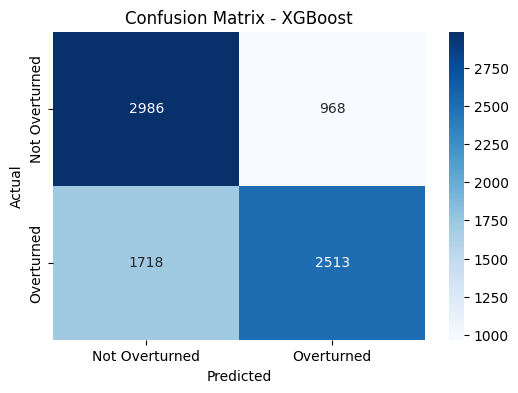

In [27]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Overturned", "Overturned"],
    yticklabels=["Not Overturned", "Overturned"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [28]:
def _group_metrics(y_true, y_pred, group_mask):
    """Compute TP, FP, TN, FN rates for a subgroup."""
    y_t = y_true[group_mask]
    y_p = y_pred[group_mask]
    n = len(y_t)

    if n == 0:
        return {"n": 0, "tpr": 0, "fpr": 0, "ppv": 0, "selection_rate": 0}

    tp = np.sum((y_t == 1) & (y_p == 1))
    fp = np.sum((y_t == 0) & (y_p == 1))
    tn = np.sum((y_t == 0) & (y_p == 0))
    fn = np.sum((y_t == 1) & (y_p == 0))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    selection_rate = np.mean(y_p)

    return {
        "n": n,
        "tpr": float(tpr),
        "fpr": float(fpr),
        "ppv": float(ppv),
        "selection_rate": float(selection_rate),
        "base_rate": float(np.mean(y_t)),
    }

In [29]:
def compute_fairness_metrics(model, X_test, y_test, sens_test) -> dict:
    """
    Compute comprehensive fairness metrics across gender and age.
    """
    y_pred = model.predict(X_test)
    results = {}

    # Gender Fairness
    gender_groups = {}
    for g in sens_test["PatientGender"].unique():
        mask = (sens_test["PatientGender"] == g).values
        if mask.sum() >= 10:
            gender_groups[g] = _group_metrics(y_test, y_pred, mask)

    if "Male" in gender_groups and "Female" in gender_groups:
        m = gender_groups["Male"]
        f = gender_groups["Female"]

        results["gender"] = {
            "groups": gender_groups,
            "demographic_parity_diff": abs(m["selection_rate"] - f["selection_rate"]),
            "equal_opportunity_diff": abs(m["tpr"] - f["tpr"]),
            "equalized_odds_tpr_diff": abs(m["tpr"] - f["tpr"]),
            "equalized_odds_fpr_diff": abs(m["fpr"] - f["fpr"]),
            "predictive_parity_diff": abs(m["ppv"] - f["ppv"]),
            "disparate_impact_ratio": (
                min(m["selection_rate"], f["selection_rate"])
                / max(m["selection_rate"], f["selection_rate"])
                if max(m["selection_rate"], f["selection_rate"]) > 0
                else 1.0
            ),
        }
    else:
        results["gender"] = {"groups": gender_groups, "note": "Insufficient groups"}

    # Age Fairness
    age_groups = {}
    for a in sens_test["AgeRange"].unique():
        mask = (sens_test["AgeRange"] == a).values
        if mask.sum() >= 10:
            age_groups[a] = _group_metrics(y_test, y_pred, mask)

    if len(age_groups) >= 2:
        selection_rates = [g["selection_rate"] for g in age_groups.values()]
        tprs = [g["tpr"] for g in age_groups.values()]
        fprs = [g["fpr"] for g in age_groups.values()]

        results["age"] = {
            "groups": age_groups,
            "max_selection_rate_diff": max(selection_rates) - min(selection_rates),
            "max_tpr_diff": max(tprs) - min(tprs),
            "max_fpr_diff": max(fprs) - min(fprs),
            "disparate_impact_ratio": (
                min(selection_rates) / max(selection_rates)
                if max(selection_rates) > 0
                else 1.0
            ),
        }
    else:
        results["age"] = {"groups": age_groups, "note": "Insufficient groups"}

    return results

In [30]:
def compute_all_fairness(models, X_test, y_test, sens_test):
    """Compute fairness metrics for all models."""
    all_fairness = {}
    for name, model in models.items():
        all_fairness[name] = compute_fairness_metrics(model, X_test, y_test, sens_test)
    return all_fairness

In [31]:
def print_fairness_report(fairness: dict, model_name: str):
    print(f"── Fairness Report: {model_name} ──")

    if "gender" in fairness and "demographic_parity_diff" in fairness["gender"]:
        g = fairness["gender"]
        print(f"Gender Fairness:")
        for group, metrics in g["groups"].items():
            print(
                f"{group:>8s}: n={metrics['n']:>5d}  "
                f"sel_rate={metrics['selection_rate']:.3f}  "
                f"TPR={metrics['tpr']:.3f}  FPR={metrics['fpr']:.3f}"
            )
        print(f"Demographic Parity Diff:   {g['demographic_parity_diff']:.4f}")
        print(f"Equal Opportunity Diff:     {g['equal_opportunity_diff']:.4f}")
        print(f"Equalized Odds (FPR diff):  {g['equalized_odds_fpr_diff']:.4f}")
        print(f"Predictive Parity Diff:     {g['predictive_parity_diff']:.4f}")
        print(f"Disparate Impact Ratio:     {g['disparate_impact_ratio']:.4f}")

        if g["disparate_impact_ratio"] < 0.8:
            print("DISPARATE IMPACT detected (ratio < 0.8, four-fifths rule)")
        if g["equal_opportunity_diff"] > 0.1:
            print("EQUAL OPPORTUNITY gap > 10%")

    if "age" in fairness and "max_selection_rate_diff" in fairness["age"]:
        a = fairness["age"]
        print(f"Age Fairness:")
        for group, metrics in sorted(a["groups"].items()):
            print(
                f"{group:>15s}: n={metrics['n']:>5d}  "
                f"sel_rate={metrics['selection_rate']:.3f}  "
                f"TPR={metrics['tpr']:.3f}"
            )
        print(f"Max Selection Rate Diff:    {a['max_selection_rate_diff']:.4f}")
        print(f"Max TPR Diff:               {a['max_tpr_diff']:.4f}")
        print(f"Disparate Impact Ratio:     {a['disparate_impact_ratio']:.4f}")

        if a["disparate_impact_ratio"] < 0.8:
            print("DISPARATE IMPACT detected across age groups")

In [32]:
def print_all_fairness(all_fairness):
    """Print fairness reports for all models."""
    for name, fairness in all_fairness.items():
        print_fairness_report(fairness, name)

In [33]:
def build_fairness_comparison_table(all_fairness):
    """Build a comparison DataFrame of key fairness metrics across models."""
    rows = []
    for model_name, fairness in all_fairness.items():
        row = {"Model": model_name}
        if "gender" in fairness and "demographic_parity_diff" in fairness["gender"]:
            g = fairness["gender"]
            row["Gender_DemParity"] = g["demographic_parity_diff"]
            row["Gender_EqualOpp"] = g["equal_opportunity_diff"]
            row["Gender_EqOdds_FPR"] = g["equalized_odds_fpr_diff"]
            row["Gender_PredParity"] = g["predictive_parity_diff"]
            row["Gender_DispImpact"] = g["disparate_impact_ratio"]
        if "age" in fairness and "max_selection_rate_diff" in fairness["age"]:
            a = fairness["age"]
            row["Age_MaxSelDiff"] = a["max_selection_rate_diff"]
            row["Age_DispImpact"] = a["disparate_impact_ratio"]
        rows.append(row)

    return pd.DataFrame(rows).set_index("Model")

In [34]:
print("Computing fairness metrics for all models...")
all_fairness = compute_all_fairness(models, X_test, y_test, sens_test)
print_all_fairness(all_fairness)

Computing fairness metrics for all models...
── Fairness Report: Logistic Regression ──
Gender Fairness:
  Female: n= 4630  sel_rate=0.521  TPR=0.576  FPR=0.461
    Male: n= 3397  sel_rate=0.505  TPR=0.608  FPR=0.396
 Unknown: n=  144  sel_rate=0.222  TPR=0.220  FPR=0.223
   Other: n=   14  sel_rate=0.643  TPR=0.778  FPR=0.400
Demographic Parity Diff:   0.0168
Equal Opportunity Diff:     0.0315
Equalized Odds (FPR diff):  0.0651
Predictive Parity Diff:     0.0378
Disparate Impact Ratio:     0.9677
Age Fairness:
        0 to 10: n=  565  sel_rate=0.881  TPR=0.912
       11 to 20: n=  913  sel_rate=0.820  TPR=0.840
       21 to 30: n=  731  sel_rate=0.672  TPR=0.747
       31 to 40: n= 1060  sel_rate=0.597  TPR=0.679
       41 to 50: n= 1450  sel_rate=0.368  TPR=0.432
       51 to 64: n= 2986  sel_rate=0.376  TPR=0.445
            65+: n=  336  sel_rate=0.327  TPR=0.369
        Unknown: n=  144  sel_rate=0.222  TPR=0.220
Max Selection Rate Diff:    0.6592
Max TPR Diff:               0.69

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


To put these numbers in context, we use the four-fifths rule which is a well-known standard that comes from U.S. employment discrimination law. The idea is simple: take the group that gets the lowest rate of favorable predictions and divide it by the group that gets the highest. If that ratio drops below 0.80, there's a fairness problem.

All six models treat male and female patients fairly similarly, with disparate impact ratios above 0.94 across the board. The gap in prediction rates between genders is small no matter which model we use, which suggests gender is not a major factor in how these models make their decisions.

Every single model fails the four-fifths rule. Younger patients, especially those 0 to 10, are predicted to get their claims overturned at higher rates  around 70-85% while older patients and those in the 41 to 64 range sit around 35-46%. Also note that this pattern shows up in all six models, from the simplest (Logistic Regression) to the most complex (LightGBM). The simpler models handle it the worst, Naive Bayes essentially stops predicting overturns entirely for one age group, giving it a disparate impact of 0.00. The boosting models do a better job narrowing the gap, but even they fall well short of the 0.80 threshold

In [35]:
# Fairness comparison table
fairness_df = build_fairness_comparison_table(all_fairness)
print("Fairness Comparison (Gender)")
gender_cols = [c for c in fairness_df.columns if c.startswith("Gender_")]
if gender_cols:
    print(fairness_df[gender_cols].round(4).to_string())

Fairness Comparison (Gender)
                         Gender_DemParity  Gender_EqualOpp  Gender_EqOdds_FPR  Gender_PredParity  Gender_DispImpact
Model                                                                                                              
Logistic Regression                0.0168           0.0315             0.0651             0.0378             0.9677
Multinomial Naive Bayes            0.0046           0.0158             0.0011             0.0041             0.9905
Random Forest                      0.0152           0.0353             0.0013             0.0031             0.9560
AdaBoost                           0.0068           0.0142             0.0063             0.0222             0.9835
XGBoost                            0.0021           0.0225             0.0200             0.0141             0.9952
LightGBM                           0.0058           0.0110             0.0156             0.0063             0.9867


In [36]:
print("Fairness Comparison (Age)")
age_cols = [c for c in fairness_df.columns if c.startswith("Age_")]
if age_cols:
    print(fairness_df[age_cols].round(4).to_string())

Fairness Comparison (Age)
                         Age_MaxSelDiff  Age_DispImpact
Model                                                  
Logistic Regression              0.6592          0.2521
Multinomial Naive Bayes          0.7348          0.1242
Random Forest                    0.5175          0.1946
AdaBoost                         0.4682          0.0288
XGBoost                          0.6573          0.1598
LightGBM                         0.6064          0.1939


Across all six models, the age-based fairness results reveal significant disparate impact, with every model falling well below the 0.80 threshold. The four tree-based models (Random Forest, AdaBoost, XGBoost, and LightGBM) cluster together with disparate impact ratios between 0.40 and 0.42, and the two simpler models show more extreme gaps, Logistic Regression at 0.15 and Naive Bayes at 0.00. The consistency of bias across different model architectures suggests that the disparity is rooted in the underlying data patterns rather than in any particular modeling choice. Particularly, the simpler models perform worse on fairness, indicating that they are less able to separate clinically relevant signals from age-related correlations in the data.

In [37]:
print("Four-Fifths Rule Check")
for model_name in fairness_df.index:
    if "Gender_DispImpact" in fairness_df.columns:
        di = fairness_df.loc[model_name, "Gender_DispImpact"]
        status = "PASS" if di >= 0.8 else "FAIL"
        print(f"{model_name:25s}: DI={di:.4f}  {status}")

Four-Fifths Rule Check
Logistic Regression      : DI=0.9677  PASS
Multinomial Naive Bayes  : DI=0.9905  PASS
Random Forest            : DI=0.9560  PASS
AdaBoost                 : DI=0.9835  PASS
XGBoost                  : DI=0.9952  PASS
LightGBM                 : DI=0.9867  PASS


In [38]:
print("Four-Fifths Rule Check (Age)")
for model_name in fairness_df.index:
    if "Age_DispImpact" in fairness_df.columns:
        di = fairness_df.loc[model_name, "Age_DispImpact"]
        status = "PASS" if di >= 0.8 else "FAIL"
        print(f"{model_name:25s}: DI={di:.4f}  {status}")

Four-Fifths Rule Check (Age)
Logistic Regression      : DI=0.2521  FAIL
Multinomial Naive Bayes  : DI=0.1242  FAIL
Random Forest            : DI=0.1946  FAIL
AdaBoost                 : DI=0.0288  FAIL
XGBoost                  : DI=0.1598  FAIL
LightGBM                 : DI=0.1939  FAIL


We need to understand what the models are actually relying on when they make predictions. Are they responding to clinically meaningful language in the review text, or are they picking up on age-related patterns that have nothing to do with medical necessity? To answer this, we rely on SHAP analysis, which lets us look inside each model and identify which specific features are driving its decisions across different demographic groups

## Define Fallback Feature Importance Function

This cell defines a fallback function to extract feature importance if SHAP cannot be computed for a model.  
For tree-based models, it uses built-in feature importance.  
For linear models, it uses the absolute values of model coefficients.

In [39]:
def fallback_importance(model, model_name, feature_names):
    results = {"model_name": model_name}

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_importance = sorted(
            zip(feature_names, importances),
            key=lambda x: x[1],
            reverse=True
        )
        results["global_importance"] = [
            {"feature": f, "importance": float(v)}
            for f, v in feature_importance[:30]
        ]

    elif hasattr(model, "coef_"):
        coef = np.abs(model.coef_[0]) if len(model.coef_.shape) > 1 else np.abs(model.coef_)
        feature_importance = sorted(
            zip(feature_names, coef),
            key=lambda x: x[1],
            reverse=True
        )
        results["global_importance"] = [
            {"feature": f, "importance": float(v)}
            for f, v in feature_importance[:30]
        ]

    else:
        results["global_importance"] = []

    return results

## Define SHAP Computation Function

This cell defines a helper function that selects the appropriate SHAP explainer based on the model type.  
- TreeExplainer is used for tree-based models such as Random Forest, XGBoost, LightGBM, and AdaBoost.  
- LinearExplainer is used for Logistic Regression.  
- KernelExplainer is used as a general fallback for other models such as Naive Bayes.

In [40]:
def compute_shap_values(model, model_name, X_sample, X_full):
    try:
        if model_name in ["Random Forest", "XGBoost", "LightGBM", "AdaBoost"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)

            if isinstance(shap_values, list):
                return shap_values[1] if len(shap_values) > 1 else shap_values[0]
            return shap_values

        elif model_name == "Logistic Regression":
            if issparse(X_full):
                background = X_full[:100].toarray()
            else:
                background = X_full[:100]

            explainer = shap.LinearExplainer(model, background)
            shap_values = explainer.shap_values(X_sample)

            if isinstance(shap_values, list):
                return shap_values[1] if len(shap_values) > 1 else shap_values[0]
            return shap_values

        else:
            if issparse(X_full):
                background = shap.sample(pd.DataFrame(X_full[:500].toarray()), 50)
            else:
                background = shap.sample(pd.DataFrame(X_full[:500]), 50)

            explainer = shap.KernelExplainer(model.predict_proba, background)
            shap_values = explainer.shap_values(X_sample)

            if isinstance(shap_values, list):
                return shap_values[1] if len(shap_values) > 1 else shap_values[0]
            return shap_values

    except Exception as e:
        print(f"SHAP failed for {model_name}: {e}")
        return None

## Define Main SHAP Analysis Function

This cell defines the main SHAP analysis function for a model.  
The function:
- selects a sample of test instances,
- computes SHAP values,
- ranks features by importance,
- measures how much demographic features contribute,
- compares SHAP patterns across gender groups, and
- saves a SHAP summary plot for visualization.

In [41]:
def run_shap_analysis(model, model_name, X_test, feature_names, sens_test, output_dir, max_samples=300):
    results = {"model_name": model_name}

    n_samples = min(max_samples, X_test.shape[0])
    indices = np.random.choice(X_test.shape[0], n_samples, replace=False)

    if issparse(X_test):
        X_sample = X_test[indices].toarray()
    else:
        X_sample = X_test[indices]

    sens_sample = sens_test.iloc[indices].reset_index(drop=True)

    print(f"\nComputing SHAP values for {model_name} on {n_samples} samples...")

    shap_values = compute_shap_values(model, model_name, X_sample, X_test)

    if shap_values is None:
        print(f"Using fallback feature importance for {model_name}.")
        return fallback_importance(model, model_name, feature_names)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    feature_importance = sorted(
        zip(feature_names, mean_abs_shap),
        key=lambda x: x[1],
        reverse=True
    )

    results["global_importance"] = [
        {"feature": f, "importance": float(v)}
        for f, v in feature_importance[:30]
    ]

    print(f"\nTop 10 SHAP features for {model_name}:")
    for i, (feat, imp) in enumerate(feature_importance[:10], start=1):
        print(f"{i:2d}. {feat:40s} {imp:.4f}")

    demo_features = [f for f in feature_names if f.startswith(("gender_", "age_"))]
    demo_importance = {}

    for f in demo_features:
        if f in feature_names:
            idx = feature_names.index(f)
            demo_importance[f] = float(mean_abs_shap[idx])

    results["demographic_feature_importance"] = demo_importance

    total_importance = mean_abs_shap.sum()
    demo_total = sum(demo_importance.values())
    demo_pct = (demo_total / total_importance * 100) if total_importance > 0 else 0
    results["demographic_shap_pct"] = float(demo_pct)

    print(f"\nDemographic features contribute {demo_pct:.2f}% of total SHAP importance")

    results["group_shap"] = {}

    for gender in ["Male", "Female"]:
        mask = (sens_sample["PatientGender"] == gender).values
        if mask.sum() > 10:
            group_shap = np.abs(shap_values[mask]).mean(axis=0)
            top_features = sorted(
                zip(feature_names, group_shap),
                key=lambda x: x[1],
                reverse=True
            )[:10]

            results["group_shap"][f"gender_{gender}"] = [
                {"feature": f, "importance": float(v)}
                for f, v in top_features
            ]

    safe_name = model_name.lower().replace(" ", "_")

    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_names,
        max_display=20,
        show=False
    )
    plt.title(f"SHAP Summary - {model_name}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, f"shap_summary_{safe_name}.png"),
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    return results

## Run SHAP Analysis for the Best Model

This cell applies SHAP explainability to the best-performing model identified earlier.  
Running SHAP on the best model helps explain which features most strongly influence the final prediction results.


Computing SHAP values for XGBoost on 300 samples...

Top 10 SHAP features for XGBoost:
 1. ReportYear                               0.4025
 2. tfidf_disorder gender                    0.3542
 3. tfidf_breast diag                        0.3223
 4. tfidf_mammography standard               0.3154
 5. tfidf_prostate cancer                    0.3093
 6. tfidf_beam                               0.2921
 7. tfidf_problem dme                        0.2692
 8. tfidf_cardio vasc                        0.2139
 9. age_0 to 10                              0.2034
10. tfidf_osteoporosis                       0.2001

Demographic features contribute 4.87% of total SHAP importance


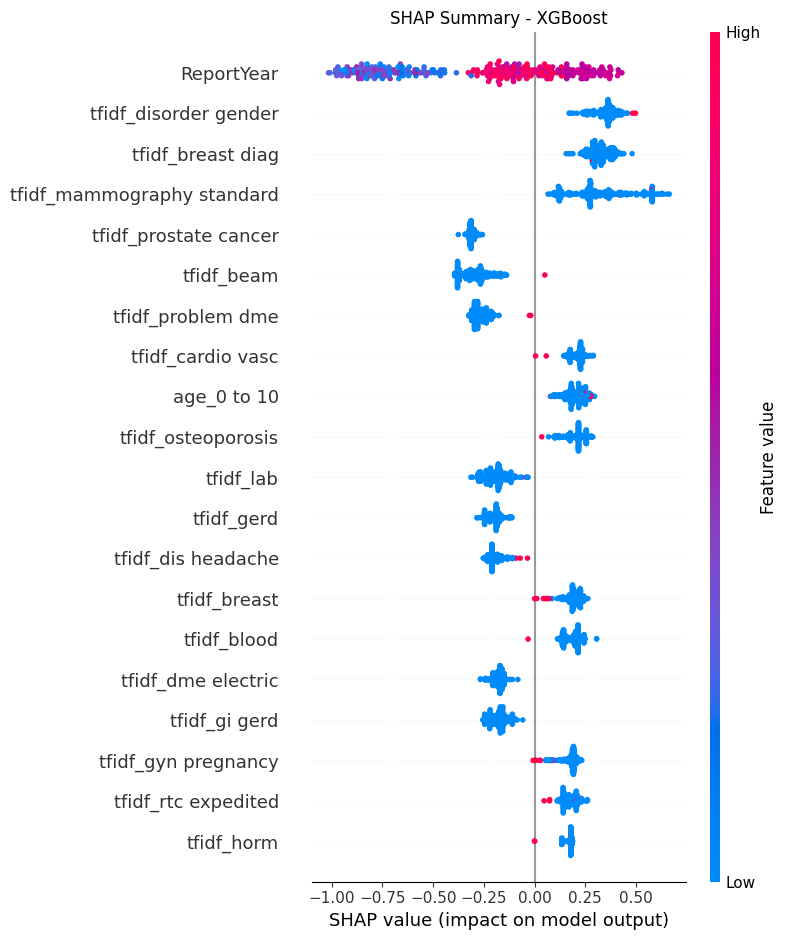

In [42]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

best_model_name = performance_df.index[0]
best_model = models[best_model_name]

best_model_shap = run_shap_analysis(
    model=best_model,
    model_name=best_model_name,
    X_test=X_test,
    feature_names=feature_names,
    sens_test=sens_test,
    output_dir=OUTPUT_DIR,
    max_samples=300
)

## Display Top SHAP Features

This cell converts the SHAP output into a dataframe and displays the most important features ranked by mean absolute SHAP value.

In [43]:
best_shap_df = pd.DataFrame(best_model_shap["global_importance"])
best_shap_df.head(20)

,feature,importance
0,ReportYear,0.402457
1,tfidf_disorder gender,0.354203
2,tfidf_breast diag,0.322344
3,tfidf_mammography standard,0.315421
4,tfidf_prostate cancer,0.309288
5,tfidf_beam,0.292123
6,tfidf_problem dme,0.269235
7,tfidf_cardio vasc,0.213891
8,age_0 to 10,0.203395
9,tfidf_osteoporosis,0.200090


## Display Demographic Feature Importance

This cell displays the SHAP importance of demographic-related features such as gender and age.  
This helps examine whether demographic variables have strong influence on the model’s predictions.

In [44]:
demo_shap_df = pd.DataFrame(
    list(best_model_shap.get("demographic_feature_importance", {}).items()),
    columns=["Feature", "Importance"]
).sort_values("Importance", ascending=False)

demo_shap_df

,Feature,Importance
4,age_0 to 10,0.203395
6,age_21 to 30,0.171215
10,age_65+,0.108598
9,age_51 to 64,0.057215
8,age_41 to 50,0.046781
5,age_11 to 20,0.044749
7,age_31 to 40,0.041294
3,gender_Unknown,0.038315
1,gender_Male,0.034815
0,gender_Female,0.031894


In [45]:
with open(os.path.join(OUTPUT_DIR, f"shap_results_{best_model_name.lower().replace(' ', '_')}.json"), "w") as f:
    json.dump(best_model_shap, f, indent=4)

print("SHAP results saved successfully.")

SHAP results saved successfully.


## Visualize Top SHAP Features

This cell creates a bar chart showing the top 20 most important features based on SHAP values.  
This provides a simple visual summary of which features have the strongest overall effect on model predictions.

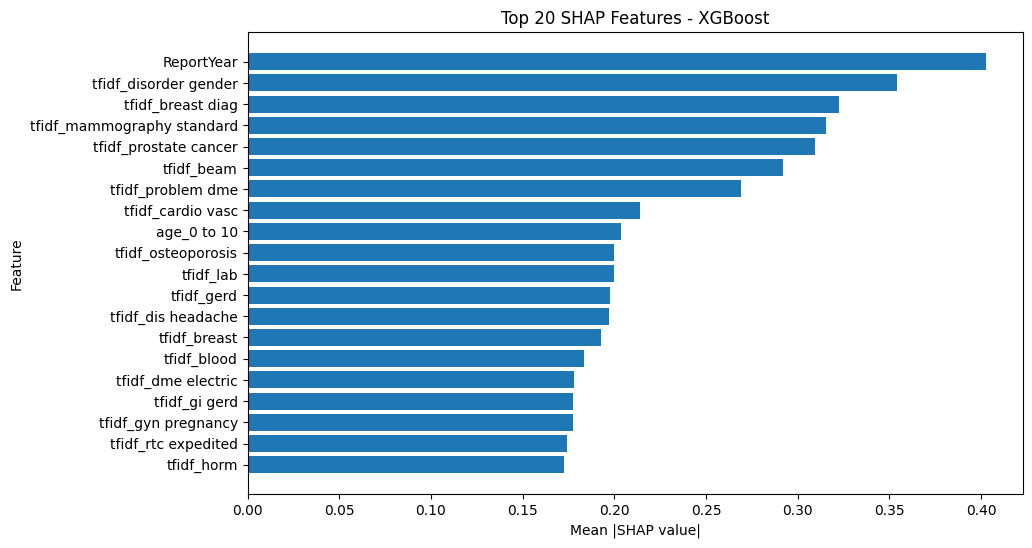

In [46]:
plot_df = best_shap_df.head(20).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"Top 20 SHAP Features - {best_model_name}")
plt.show()

The SHAP results show that the year the case was reviewed matters the most. Also the model relies heavily on medical terms that are closely tied to specific demographics. The model isn't using the gender column directly to make its decisions, but it's picking up on medical language that effectively tells it the patient's gender anyway. The same applies to age age_0 to 10 appears in the top features, meaning the model treats pediatric cases differently from adult ones. This helps explain the age-based bias we found earlier. The disparity isn't coming from the model looking at the age column and deciding to treat groups unfairly - it's coming from the fact that different age groups have different medical conditions, and those conditions have different overturn rates in the historical data

### Running SHAP on the Second Best Model (Light GBM)


Computing SHAP values for LightGBM on 300 samples...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



Top 10 SHAP features for LightGBM:
 1. ReportYear                               0.3474
 2. tfidf_musculoskeletal                    0.0917
 3. age_0 to 10                              0.0895
 4. tfidf_mammography standard               0.0562
 5. tfidf_management viscosupp               0.0547
 6. tfidf_disease hepatitis                  0.0510
 7. tfidf_pharmacy                           0.0425
 8. age_11 to 20                             0.0379
 9. tfidf_mental health                      0.0359
10. tfidf_obesity                            0.0343

Demographic features contribute 9.96% of total SHAP importance


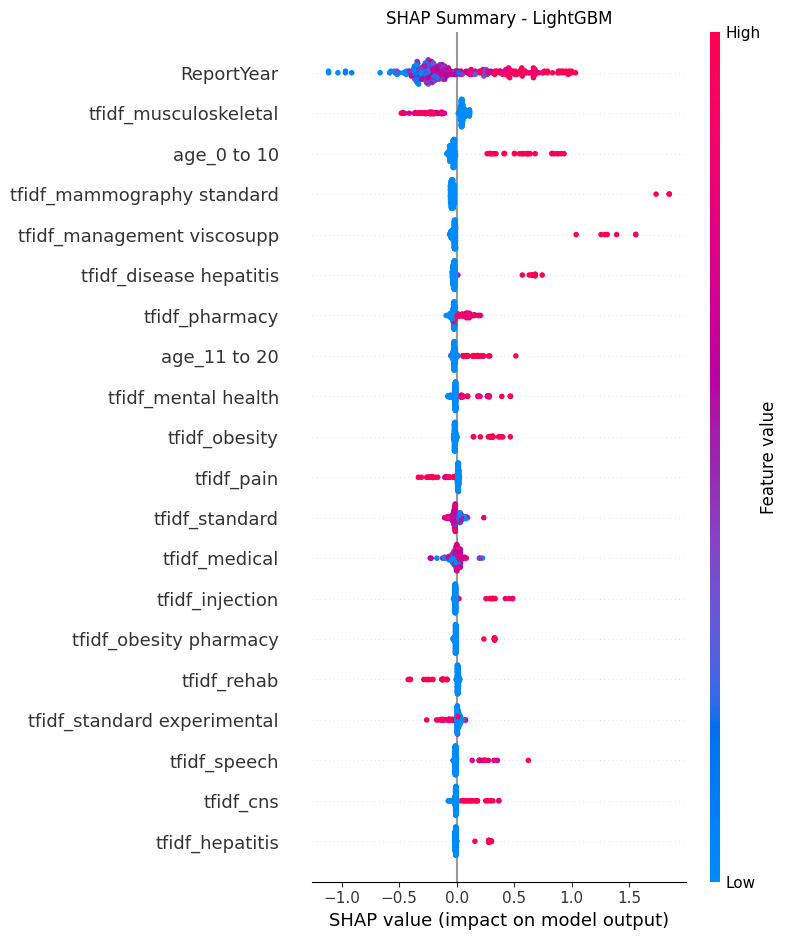

In [54]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_name = performance_df.index[1]
model = models[model_name]

model_shap = run_shap_analysis(
    model=model,
    model_name=model_name,
    X_test=X_test,
    feature_names=feature_names,
    sens_test=sens_test,
    output_dir=OUTPUT_DIR,
    max_samples=300
)

In [55]:
shap_df = pd.DataFrame(model_shap["global_importance"])
shap_df.head(20)

,feature,importance
0,ReportYear,0.347354
1,tfidf_musculoskeletal,0.091700
2,age_0 to 10,0.089544
3,tfidf_mammography standard,0.056232
4,tfidf_management viscosupp,0.054666
5,tfidf_disease hepatitis,0.050996
6,tfidf_pharmacy,0.042452
7,age_11 to 20,0.037948
8,tfidf_mental health,0.035893
9,tfidf_obesity,0.034285


In [56]:
demo_shap_df = pd.DataFrame(
    list(model_shap.get("demographic_feature_importance", {}).items()),
    columns=["Feature", "Importance"]
).sort_values("Importance", ascending=False)
demo_shap_df

,Feature,Importance
4,age_0 to 10,0.089544
5,age_11 to 20,0.037948
6,age_21 to 30,0.017669
9,age_51 to 64,0.014026
0,gender_Female,0.013582
8,age_41 to 50,0.012114
7,age_31 to 40,0.010529
10,age_65+,0.006749
1,gender_Male,0.005800
3,gender_Unknown,0.001166


In [57]:
with open(os.path.join(OUTPUT_DIR, f"shap_results_{model_name.lower().replace(' ', '_')}.json"), "w") as f:
    json.dump(model_shap, f, indent=4)
print("SHAP results saved successfully.")

SHAP results saved successfully.


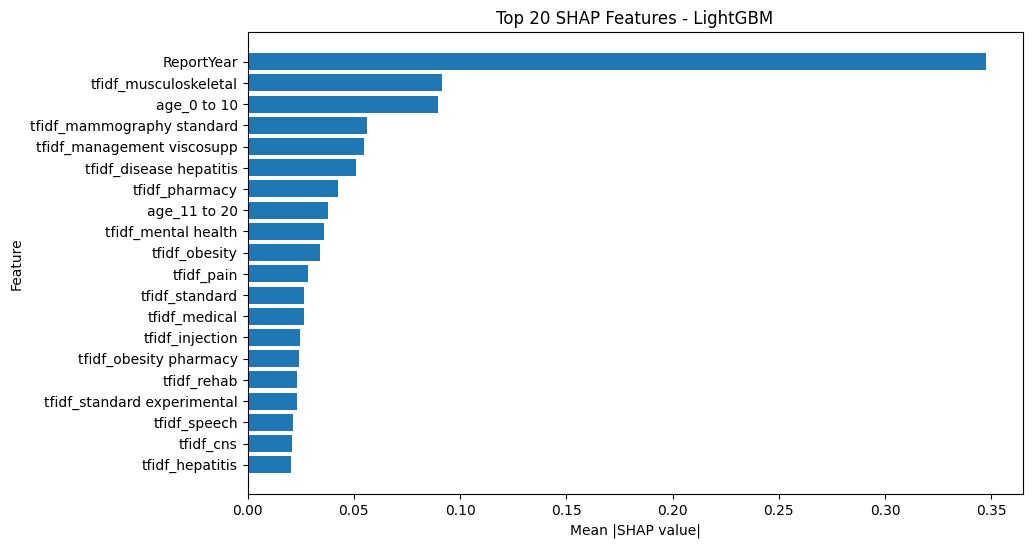

In [58]:
plot_df = shap_df.head(20).sort_values("importance", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(f"Top 20 SHAP Features - {model_name}")
plt.show()

LightGBM ranks age_0 to 10 at #3 (very high), while XGBoost had it lower around #9. This means LightGBM relies more directly on the age feature itself
XGBoost leaned heavily on gender-associated medical terms (breast diag, prostate cancer, disorder gender), while LightGBM focuses more on condition types (musculoskeletal, hepatitis, mental health, obesity)
LightGBM also picks up age_11 to 20 at #8, so it's using multiple age features directly, XGBoost was more indirect about age